# Домашнє завдання до модуля «Основи PyTorch»
## Прогнозування міцності бетону (Concrete Strength Prediction)


In [149]:
import warnings

from IPython.display import display

# filter warnings
warnings.filterwarnings('ignore')

import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Налаштування відтворюваності та стилю графіків
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")


## 1. Попередній аналіз даних (EDA) та підготовка

Завантажуємо датасет **Concrete Compressive Strength** із відкритих джерел (UCI / OpenML).


In [150]:
path = kagglehub.dataset_download("mchilamwar/predict-concrete-strength")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'ConcreteStrengthData.csv'))

print(df.head())

# Перейменуємо колонки для зручності
df.columns = [
    'Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
    'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
    'Age', 'Strength'
]



Path to dataset files: C:\Users\elina\.cache\kagglehub\datasets\mchilamwar\predict-concrete-strength\versions\1
   CementComponent   BlastFurnaceSlag  FlyAshComponent  WaterComponent  \
0             540.0               0.0              0.0           162.0   
1             540.0               0.0              0.0           162.0   
2             332.5             142.5              0.0           228.0   
3             332.5             142.5              0.0           228.0   
4             198.6             132.4              0.0           192.0   

   SuperplasticizerComponent  CoarseAggregateComponent  \
0                        2.5                    1040.0   
1                        2.5                    1055.0   
2                        0.0                     932.0   
3                        0.0                     932.0   
4                        0.0                     978.4   

   FineAggregateComponent  AgeInDays  Strength  
0                   676.0         28     79.9

In [151]:
print("Перші 5 рядків датасету:")
display(df.head())

print("\nСтатистичний опис даних:")
display(df.describe())

print("\nПеревірка на пропущені значення:")
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(1),
    'nunique': df.nunique()
})
display(summary)


Перші 5 рядків датасету:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30



Статистичний опис даних:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000



Перевірка на пропущені значення:


,dtype,nulls,null_%,nunique
Cement,float64,0,0.0,278
Blast_Furnace_Slag,float64,0,0.0,185
Fly_Ash,float64,0,0.0,156
Water,float64,0,0.0,195
Superplasticizer,float64,0,0.0,111
Coarse_Aggregate,float64,0,0.0,284
Fine_Aggregate,float64,0,0.0,302
Age,int64,0,0.0,14
Strength,float64,0,0.0,845


### Створення нової ознаки Components (кількість ненульових компонент)

In [152]:
# Рахуємо кількість колонок зі складовими, де значення > 0
# виключаємо 'Strength', Age не є компонентом суміші

components_cols = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate']
df['Components'] = (df[components_cols] > 0).sum(axis=1)
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,5


In [153]:
print("\nМатриця кореляцій:")
print(df.corr())


Матриця кореляцій:
                      Cement  Blast_Furnace_Slag   Fly_Ash     Water  \
Cement              1.000000           -0.275216 -0.397467 -0.081587   
Blast_Furnace_Slag -0.275216            1.000000 -0.323580  0.107252   
Fly_Ash            -0.397467           -0.323580  1.000000 -0.256984   
Water              -0.081587            0.107252 -0.256984  1.000000   
Superplasticizer    0.092386            0.043270  0.377503 -0.657533   
Coarse_Aggregate   -0.109349           -0.283999 -0.009961 -0.182294   
Fine_Aggregate     -0.222718           -0.281603  0.079108 -0.450661   
Age                 0.081946           -0.044246 -0.154371  0.277618   
Strength            0.497832            0.134829 -0.105755 -0.289633   
Components         -0.284820            0.212018  0.679695 -0.377101   

                    Superplasticizer  Coarse_Aggregate  Fine_Aggregate  \
Cement                      0.092386         -0.109349       -0.222718   
Blast_Furnace_Slag          0.043270   

### Візуалізація даних

Матриця кореляцій та розподіл цільової змінної (`Strength`).


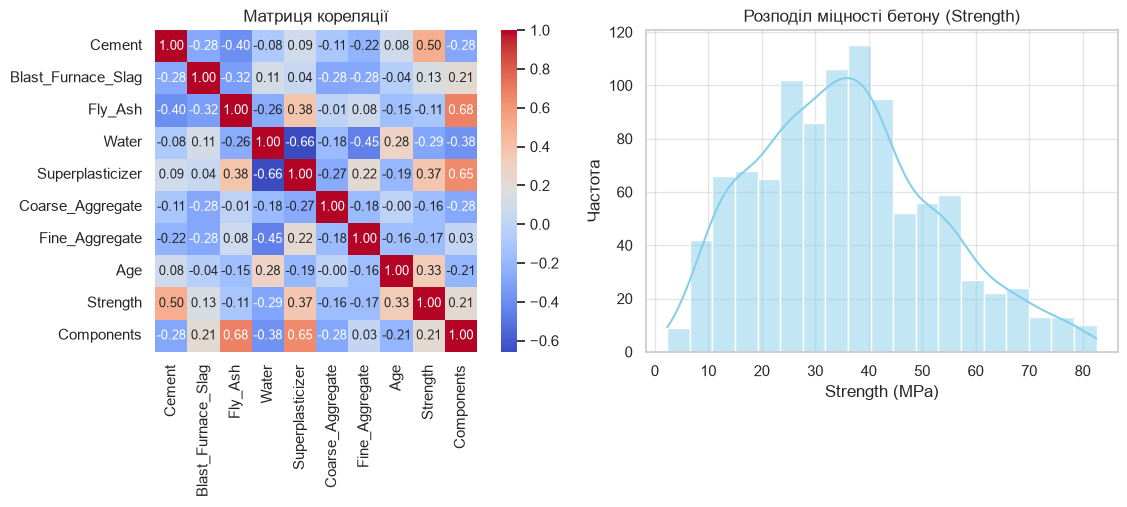

In [154]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, annot_kws={"size": 9})
plt.title('Матриця кореляції')

plt.subplot(1, 2, 2)
sns.histplot(df['Strength'], kde=True, color='skyblue')
plt.title('Розподіл міцності бетону (Strength)')
plt.xlabel('Strength (MPa)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()


Зв’язок ознак із міцністю бетону:

* Cement: 0.50 Найсильніший позитивний зв’язок: більше цементу зазвичай пов’язано з більшою міцністю
* Superplasticizer: 0.37
* Age: 0.33
* Water: −0.29 Найпомітніший негативний зв’язок: більша кількість води пов’язана зі зниженням міцності

Найсильніші зв’язки між ознаками
* Water ↔ Superplasticizer : −0.658 — найсильніша кореляція в матриці. У сумішах із більшою кількістю суперпластифікатора зазвичай використовується менше води.
* Water ↔ Fine_Aggregate: −0.451 — помірний негативний зв’язок.
* Cement ↔ Fly_Ash: −0.397 — збільшення частки золи часто супроводжується зменшенням цементу.
* Fly_Ash ↔ Superplasticizer: 0.378 — помірний позитивний зв’язок.
* Blast_Furnace_Slag ↔ Fly_Ash: −0.324 — слабкий або помірний негативний зв’язок.
* Blast_Furnace_Slag ↔ Coarse_Aggregate: −0.284.
* Blast_Furnace_Slag ↔ Fine_Aggregate: −0.282.
* Water ↔ Age: 0.278.

Надзвичайно високих кореляцій між ознаками, наприклад \(|r| > 0.8\), немає. Тому матриця не показує критичної **мультиколінеарності** .

## 2. Розділення даних та нормалізація

1. Відокремлюємо ознаки ($X$) та цільову змінну ($y$).
2. Розділяємо на навчальну (80%) та тестову (20%) вибірки.
3. Виконуємо стандартизацію вхідних ознак за допомогою `StandardScaler`.


In [155]:
X = df.drop(columns=['Strength']).values
y = df['Strength'].values.reshape(-1, 1)

# Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Нормалізація вхідних даних
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Перетворення в тензори PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Створення DataLoader для батчевої обробки
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Розмір навчальної вибірки: {X_train.shape[0]}")
print(f"Розмір тестової вибірки: {X_test.shape[0]}")


Розмір навчальної вибірки: 824
Розмір тестової вибірки: 206


### 3. Створення класу нейронної мережі

Розробляємо базову та оптимізовану архітектуру нейронної мережі для регресії.

Для задач регресії на вихідному шарі зазвичай використовується лінійний шар без функції активації (або з активацією Identity), щоб модель мала змогу передбачати довільні дійсні числа в будь-якому діапазоні.

In [156]:
class ConcreteStrengthNN(nn.Module):
    def __init__(self, input_dim):
        super(ConcreteStrengthNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = ConcreteStrengthNN(input_dim)
display(model)


ConcreteStrengthNN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

### 4. Налаштування та обґрунтування навчання

* **Функція втрат (`MSELoss`)**: підходить для задачі регресії, оскільки вона карає великі відхилення від цільового значення більш суворо, ніж малі.
* **Оптимізатор (`Adam`)**: забезпечує адаптивний вибір швидкості навчання для кожного параметра, що пришвидшує збіжність порівняно зі звичайним SGD.


In [157]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
EPOCHS = 150


### 5. Навчання моделі


In [158]:
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS} | Train MSE Loss: {epoch_loss:.4f}")


Epoch 001/150 | Train MSE Loss: 1224.9980
Epoch 020/150 | Train MSE Loss: 101.9873
Epoch 040/150 | Train MSE Loss: 46.5206
Epoch 060/150 | Train MSE Loss: 28.2525
Epoch 080/150 | Train MSE Loss: 20.2266
Epoch 100/150 | Train MSE Loss: 19.2796
Epoch 120/150 | Train MSE Loss: 16.4044
Epoch 140/150 | Train MSE Loss: 18.7816


### 6. Оцінка моделі та метрики

Обчислюємо метрики MSE, MAE та $R^2$ на тестовій вибірці.

* **MSE (Mean Squared Error)**: показує середню квадратну похибку.
* **MAE (Mean Absolute Error)**: показує середнє абсолютне відхилення у тих самих одиницях (МПа).
* **$R^2$ (Коефіцієнт детермінації)**: оцінює, яку частку дисперсії цільової змінної пояснює модель (чим ближче до 1.0, тим краще).


In [159]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.detach().cpu().numpy()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Результати базової моделі на тестовій вибірці ---")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²:  {r2:.4f}")



--- Результати базової моделі на тестовій вибірці ---
MSE: 38.75
MAE: 4.58
R²:  0.8496


### 7. Візуалізація результатів


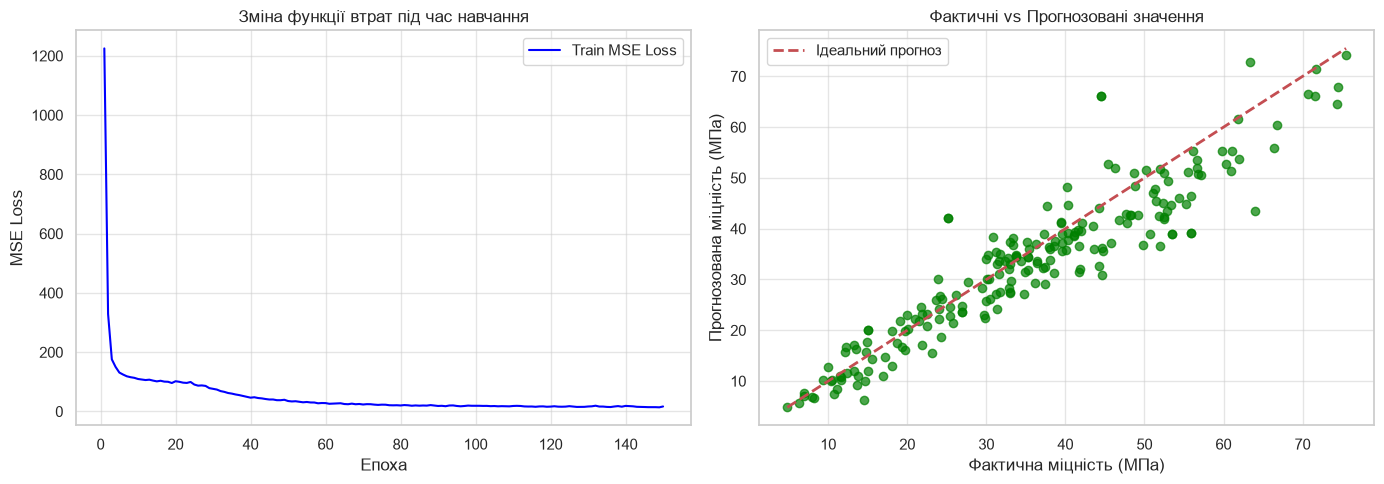

In [160]:
plt.figure(figsize=(14, 5))

# Графік функцій втрат
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train MSE Loss', color='blue')
plt.title('Зміна функції втрат під час навчання')
plt.xlabel('Епоха')
plt.ylabel('MSE Loss')
plt.legend()

# Графік Прогнозовані vs Фактичні значення
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ідеальний прогноз')
plt.title('Фактичні vs Прогнозовані значення')
plt.xlabel('Фактична міцність (МПа)')
plt.ylabel('Прогнозована міцність (МПа)')
plt.legend()

plt.tight_layout()
plt.show()


### 8. Оптимізація моделі (Додатковий експеримент)

Спробуємо покращити результат за допомогою:
* Додавання **Batch Normalization** та **Dropout** для регуляризації.
* Використання функції активації **SiLU/LeakyReLU**.
* Застосування адаптивного регулятора швидкості навчання (`ReduceLROnPlateau`).


In [161]:
class OptimizedConcreteNN(nn.Module):
    def __init__(self, input_dim):
        super(OptimizedConcreteNN, self).__init__()
        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.SiLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

opt_model = OptimizedConcreteNN(input_dim)
opt_optimizer = optim.AdamW(opt_model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_optimizer, mode='min', factor=0.5, patience=15)
opt_criterion = nn.MSELoss()

opt_epochs = 200
opt_losses = []

for epoch in range(1, opt_epochs + 1):
    opt_model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        opt_optimizer.zero_grad()
        preds = opt_model(batch_X)
        loss = opt_criterion(preds, batch_y)
        loss.backward()
        opt_optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    opt_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

opt_model.eval()
with torch.no_grad():
    y_opt_pred = opt_model(X_test_tensor).detach().cpu().numpy()

opt_mse = mean_squared_error(y_test, y_opt_pred)
opt_mae = mean_absolute_error(y_test, y_opt_pred)
opt_r2 = r2_score(y_test, y_opt_pred)

print("\n--- Результати oптимізованої моделі vs базової моделі---")
print(f"MSE: {opt_mse:.2f} vs {mse:.2f}")
print(f"MAE: {opt_mae:.2f} vs {mae:.2f}")
print(f"R²:  {opt_r2:.4f} vs {r2:.2f}")



--- Результати oптимізованої моделі vs базової моделі---
MSE: 26.59 vs 38.75
MAE: 4.03 vs 4.58
R²:  0.8968 vs 0.85


### 9. Висновки

1. **Аналіз вихідних даних**:
    -  На міцність бетону найбільший позитивний вплив мають кількість
        -  `Cement`, $r = 0.50$
        -  `Superplasticizer`, $r = 0.37$
        -  `Age` вік бетону у днях, $r = 0.33$
    -  Найбільший негативний вплив має `Water`, $r = -0.29$

2. **Результати моделей**:
   - Базова модель досягла **хорошиx** та **відмінниx** показників за критеріями оцінювання.
       -  $MSE - 38.75$ : хороший
       -  $MAE - 4.58$ : відмінний
       -  $R^2 - 0.85$ : відмінний

   - Оптимізована модель із залученням BatchNorm, Dropout та SiLU активацій показала **відмінні** результати за всіма метриками. Застовані зміни в оптимізованій моделі:
      -   (Capacity): Ширина прихованих шарів збільшена з 64 -> 32 до 128 -> 64 -> 32. Це дозволяє мережі моделювати більш складні, нелінійні взаємозв'язки між різними компонентами бетону
      -   nn.BatchNorm1d Пакетна нормалізація. Нормалізує виходи (активації) попереднього шару для кожного міні-батчу так, щоб їхнє середнє дорівнювало 0, а дисперсія — 1.
      -  SiLU замість ReLU. У ReLU від'ємні значення повністю обнуляються, що може призвести до "відмирання" нейронів (коли нейрон назавжди припиняє оновлюватися). SiLU дозволяє невеликим від'ємним градієнтам проходити далі.
      -  Dropout. Під час кожного кроку навчання випадковим чином "виключає" (прирівнює до 0) 10% нейронів шару. Забігає ко-адаптації нейронів, змушуючи мережу вчитися стійкіших ознак, що зменшує залежність від окремих зразків у навчальній вибірці.
      -  Оптимізатор AdamW замість Adam. Значно краща регуляризація та більша узагальнююча здатність моделі на тестових даних.
      -  ReduceLROnPlateau. Адаптивний регулятор швидкості навчання. Стежить за показником втрат (epoch_loss). Якщо похибка перестає зменшуватися протягом кількох епох (patience=15), регулятор зменшує learning rate удвічі (factor=0.5).

3. **Шляхи подальшого покращення**:
   - Інженерія ознак (Feature Engineering), наприклад, розрахунок водоцементного співвідношення (`Water` / `Cement`).
   - Крос-валідація (K-Fold). Оскільки датасет має невеликий розмір (1030 рядків), використання 5-Fold CV замість одного train/test split дало б більш об'єктивне оцінювання усередненої якості моделей.
